In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [7]:
cars_data=pd.read_csv('Toyota.csv',index_col=0,na_values=["??","????"])


In [8]:
cars_data2=cars_data.copy()

In [10]:
cars_data.head(5)

,Price,Age,KM,FuelType,HP,MetColor,Automatic,CC,Doors,Weight
0,13500,23.0,46986.0,Diesel,90.0,1.0,0,2000,three,1165
1,13750,23.0,72937.0,Diesel,90.0,1.0,0,2000,3,1165
2,13950,24.0,41711.0,Diesel,90.0,NaN,0,2000,3,1165
3,14950,26.0,48000.0,Diesel,90.0,0.0,0,2000,3,1165
4,13750,30.0,38500.0,Diesel,90.0,0.0,0,2000,3,1170


In [11]:
pd.crosstab(index=cars_data2['FuelType'],columns="count",dropna=True)

col_0,count
FuelType,
CNG,15
Diesel,144
Petrol,1177


In [12]:
pd.crosstab(index=cars_data2['FuelType'],columns=cars_data2["Automatic"],dropna=True)

Automatic,0,1
FuelType,,
CNG,15,0
Diesel,144,0
Petrol,1104,73


In [14]:
pd.crosstab(columns=cars_data2['FuelType'],index=cars_data2["Automatic"],dropna=True)

FuelType,CNG,Diesel,Petrol
Automatic,,,
0,15,144,1104
1,0,0,73


In [15]:
#joint probabilty

pd.crosstab(index=cars_data["Automatic"],
           columns=cars_data2["FuelType"],normalize=True,dropna=True)

FuelType,CNG,Diesel,Petrol
Automatic,,,
0,0.011228,0.107784,0.826347
1,0.000000,0.000000,0.054641


In [16]:
#margin probabilty

pd.crosstab(index=cars_data["Automatic"],
           columns=cars_data2["FuelType"],normalize=True,dropna=True,margins=True)

FuelType,CNG,Diesel,Petrol,All
Automatic,,,,
0,0.011228,0.107784,0.826347,0.945359
1,0.000000,0.000000,0.054641,0.054641
All,0.011228,0.107784,0.880988,1.000000


In [18]:
#conditional probabilty
pd.crosstab(index=cars_data["Automatic"],
           columns=cars_data2["FuelType"],normalize='index',dropna=True,margins=True)


FuelType,CNG,Diesel,Petrol
Automatic,,,
0,0.011876,0.114014,0.874109
1,0.000000,0.000000,1.000000
All,0.011228,0.107784,0.880988


In [35]:
#conditional probabilty
pd.crosstab(index=cars_data["Automatic"],
           columns=cars_data2["FuelType"],normalize='columns',dropna=True,margins=True)


FuelType,CNG,Diesel,Petrol,All
Automatic,,,,
0,1.0,1.0,0.937978,0.945359
1,0.0,0.0,0.062022,0.054641


In [29]:
numerical_data=cars_data2.select_dtypes(exclude=[object,float])

In [30]:
numerical_data.corr(method="pearson")

,Price,Automatic,CC,Weight
Price,1.000000,0.033081,0.165067,0.581198
Automatic,0.033081,1.000000,-0.069321,0.057249
CC,0.165067,-0.069321,1.000000,0.651450
Weight,0.581198,0.057249,0.651450,1.000000


In [32]:
numerical_data.corr(method="spearman")

,Price,Automatic,CC,Weight
Price,1.000000,0.042542,0.118579,0.415687
Automatic,0.042542,1.000000,-0.059122,0.090042
CC,0.118579,-0.059122,1.000000,0.683772
Weight,0.415687,0.090042,0.683772,1.000000


In [33]:
numerical_data.corr(method="kendall")

,Price,Automatic,CC,Weight
Price,1.000000,0.035114,0.094611,0.313279
Automatic,0.035114,1.000000,-0.055211,0.075632
CC,0.094611,-0.055211,1.000000,0.568306
Weight,0.313279,0.075632,0.568306,1.000000


In [36]:
cars_data

,Price,Age,KM,FuelType,HP,MetColor,Automatic,CC,Doors,Weight
0,13500,23.0,46986.0,Diesel,90.0,1.0,0,2000,three,1165
1,13750,23.0,72937.0,Diesel,90.0,1.0,0,2000,3,1165
2,13950,24.0,41711.0,Diesel,90.0,NaN,0,2000,3,1165
3,14950,26.0,48000.0,Diesel,90.0,0.0,0,2000,3,1165
4,13750,30.0,38500.0,Diesel,90.0,0.0,0,2000,3,1170
...,...,...,...,...,...,...,...,...,...,...
1431,7500,NaN,20544.0,Petrol,86.0,1.0,0,1300,3,1025
1432,10845,72.0,NaN,Petrol,86.0,0.0,0,1300,3,1015
1433,8500,NaN,17016.0,Petrol,86.0,0.0,0,1300,3,1015
1434,7250,70.0,NaN,NaN,86.0,1.0,0,1300,3,1015


In [43]:
sns.boxplot(x=cars_data["FuelType"],y=cars_data["Price"],hue=cars_data["Automatic"])


<Axes: xlabel='FuelType', ylabel='Price'>

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_20628\1113578713.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(cars_data["Price"],ax=ax_hist,kde=False,bins=5, hist_kws={"edgecolor": "white"})


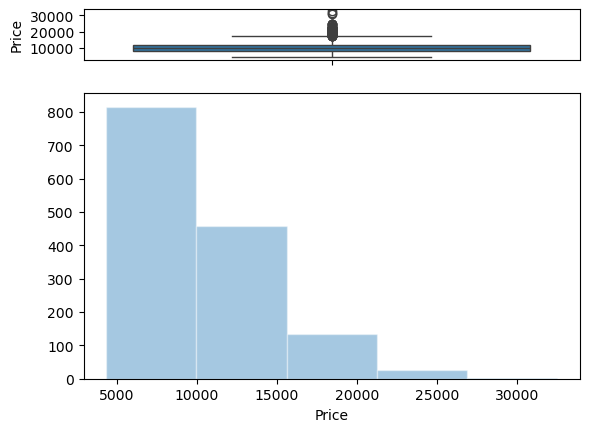

In [58]:
f,(ac_box,ax_hist)=plt.subplots(2,gridspec_kw={"height_ratios":(.15,.85)})
sns.boxplot(cars_data["Price"],ax=ac_box)
sns.distplot(cars_data["Price"],ax=ax_hist,kde=False,bins=5, hist_kws={"edgecolor": "white"})
plt.show()

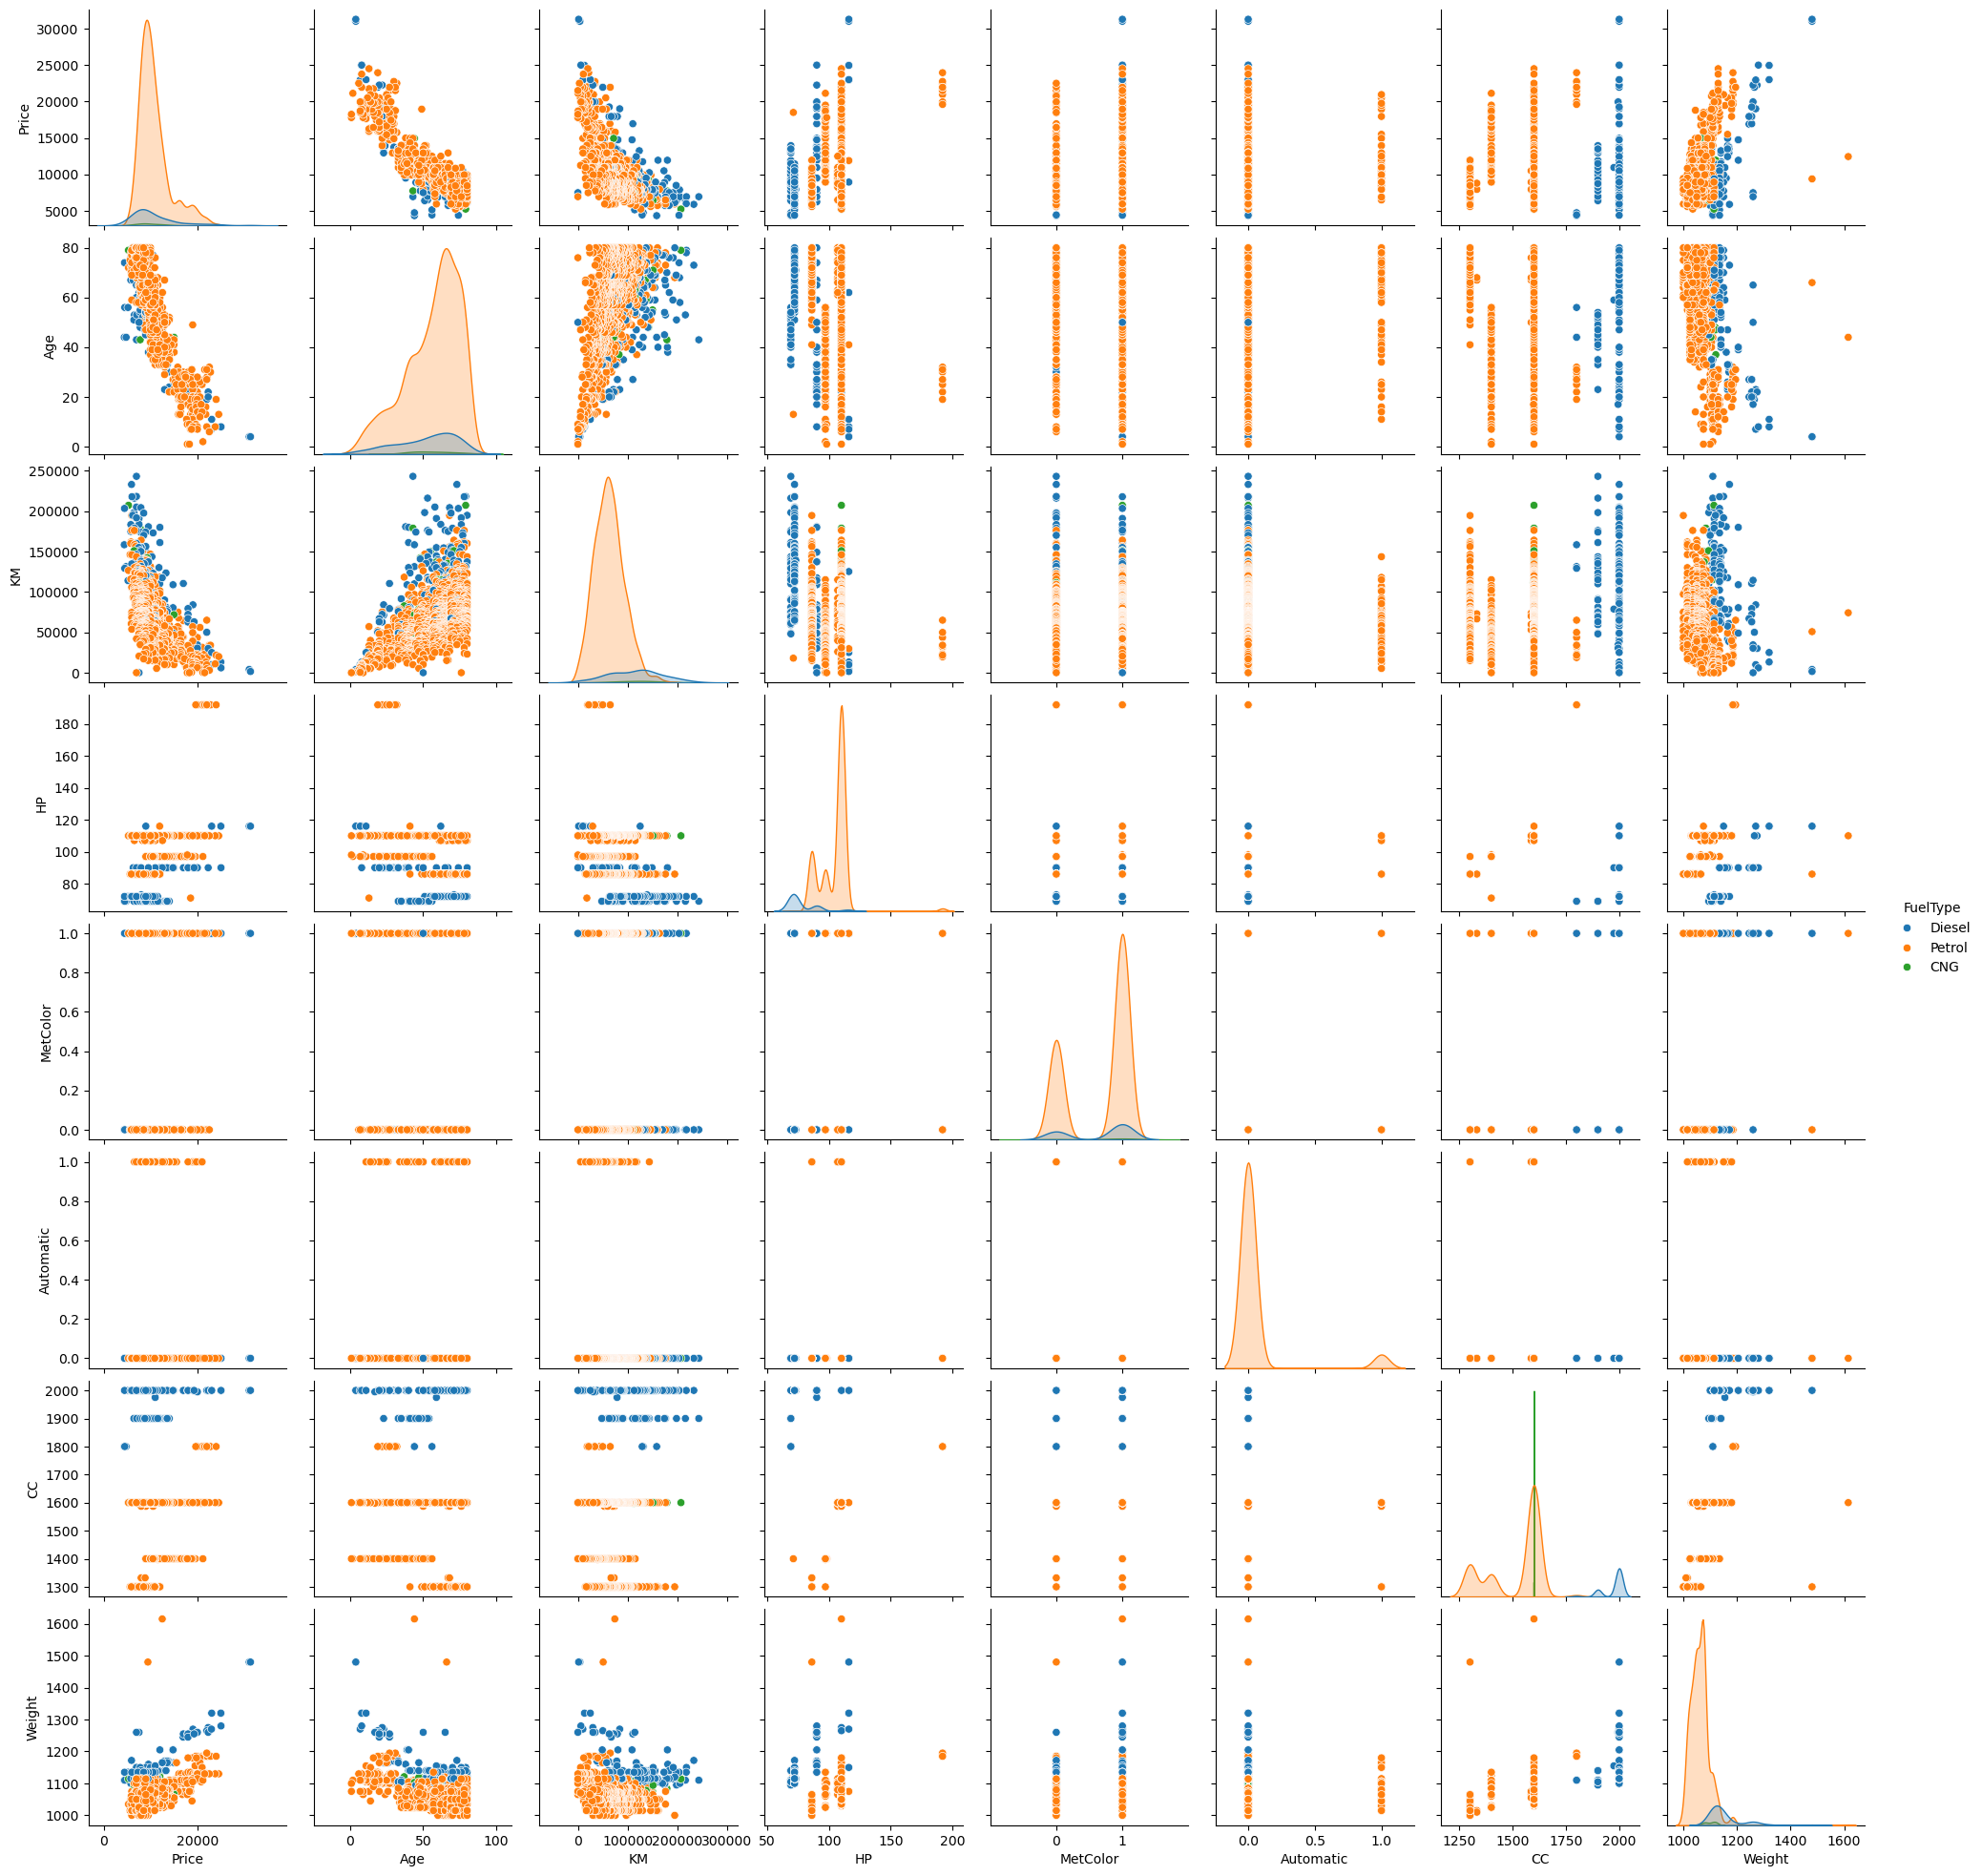

In [59]:
sns.pairplot(cars_data,kind="scatter",hue="FuelType")
plt.show()